# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax

from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

In [2]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data preparation

In [3]:
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[-1,: , 44,44]
# ATTENTION: here reaction_HF_test is a time parameter (the name is kept not to find issues)

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]
U_HF_test_original=U_HF_test

noise_stddev1=[0.00025,0.00015, 0.00025, 0.00015]
noise_stddev2=[0.01,0.005,0.02,0.005]
(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(8*np.pi*reaction_HF_test[:, 0]))]


NepoHF = 250  # number of epochs for second NN: NN_HF
Nhf = 200

permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation][0:Nhf]
U_HF = U_HF_test[permutation][0:Nhf]


# Neural Network

In [4]:

name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()

best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
                



{'kernel_init': 'uniform', 'l2weight': 0.0002588943618918075, 'lr': 0.008365144388542751, 'nodes': 6.0, 'opt': 'Adam'}


In [6]:
####################    NN training and PREDICTION    #######################

print("\nHF Model:")

model= NetworkFactory.build_network("HF",params=best_params,data_train=reaction_HF,output_train=U_HF,N=NepoHF,n=Nhf,do_HPO=False,verbose=False)
UHF = model.prediction(reaction_HF_test_original)

(mse_HF,R_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)

26/26 [==============================] - 0s 2ms/step
Elapsed time:  4.356877699989127

HF Model:
Elapsed time:  4.115318099997239

HF Model:
Test MSE: 0.04506870489840867
Test MAE: 0.17966185909981724
Test RMSE: 0.21229391159053213
R^2: 0.580796527882633


# POST PROCESSING

26/26 [==============================] - 0s 2ms/step


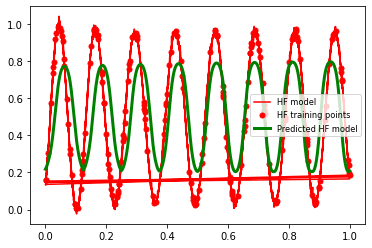

In [7]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[:,0], U_HF, "ro", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test_original[:,0],
    model.prediction(reaction_HF_test_original),
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [8]:
########################     SAVE the OUTPUT      ##########################

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! change the name of the new folder !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
os.makedirs("NNHF_HF_200_250steps_noise_fourier")

R2_HF = pandas.DataFrame({"R2_HF": [R_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [mse_HF]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./NNHF_HF_200_250steps_noise_fourier/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNHF_HF_200_250steps_noise_fourier/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
